In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor 

In [4]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df['region'].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [7]:
df['sex'].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [8]:
df['children'].unique()

array([0, 1, 3, 2, 5, 4])

In [12]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [16]:
df['charges'] = df['charges'].apply(lambda x: round(x))
df['bmi'] = df['bmi'].apply(lambda x: round(x))

In [17]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,28,0,yes,southwest,16885
1,18,male,34,1,no,southeast,1726
2,28,male,33,3,no,southeast,4449
3,33,male,23,0,no,northwest,21984
4,32,male,29,0,no,northwest,3867


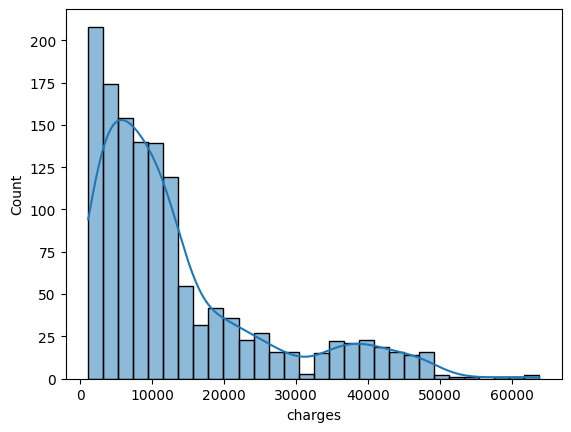

In [20]:
sns.histplot(df['charges'], kde=True)
plt.show()

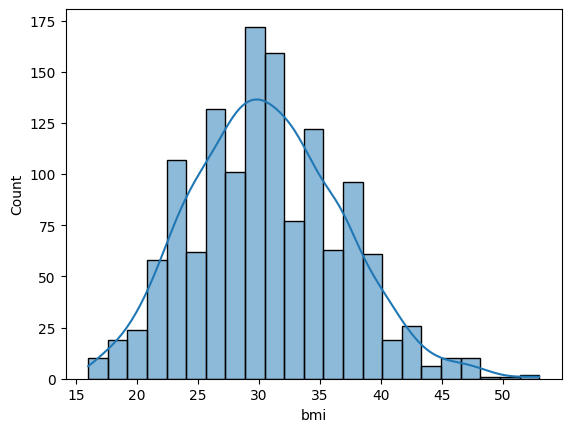

In [21]:
sns.histplot(df['bmi'], kde=True)
plt.show()

In [24]:
df.groupby('region')['charges'].mean()

region
northeast    13406.354938
northwest    12417.578462
southeast    14735.414835
southwest    12346.929231
Name: charges, dtype: float64

In [25]:
df.groupby('region')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
northeast,324.0,13406.354938,11255.798963,1695.0,5194.75,10057.5,16687.50,58571.0
northwest,325.0,12417.578462,11072.266969,1621.0,4720.00,8966.0,14712.00,60021.0
southeast,364.0,14735.414835,13971.097298,1122.0,4440.50,9294.5,19526.25,63770.0
southwest,325.0,12346.929231,11557.200928,1242.0,4751.00,8799.0,13463.00,52591.0


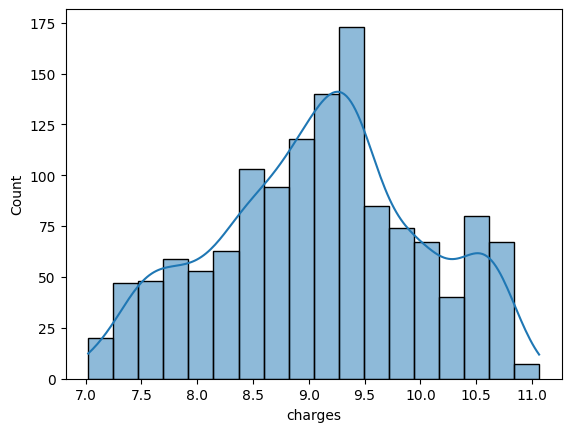

In [26]:
df['charges'] = df['charges'].apply(lambda x: np.log1p(x))
sns.histplot(df['charges'], kde=True)
plt.show()

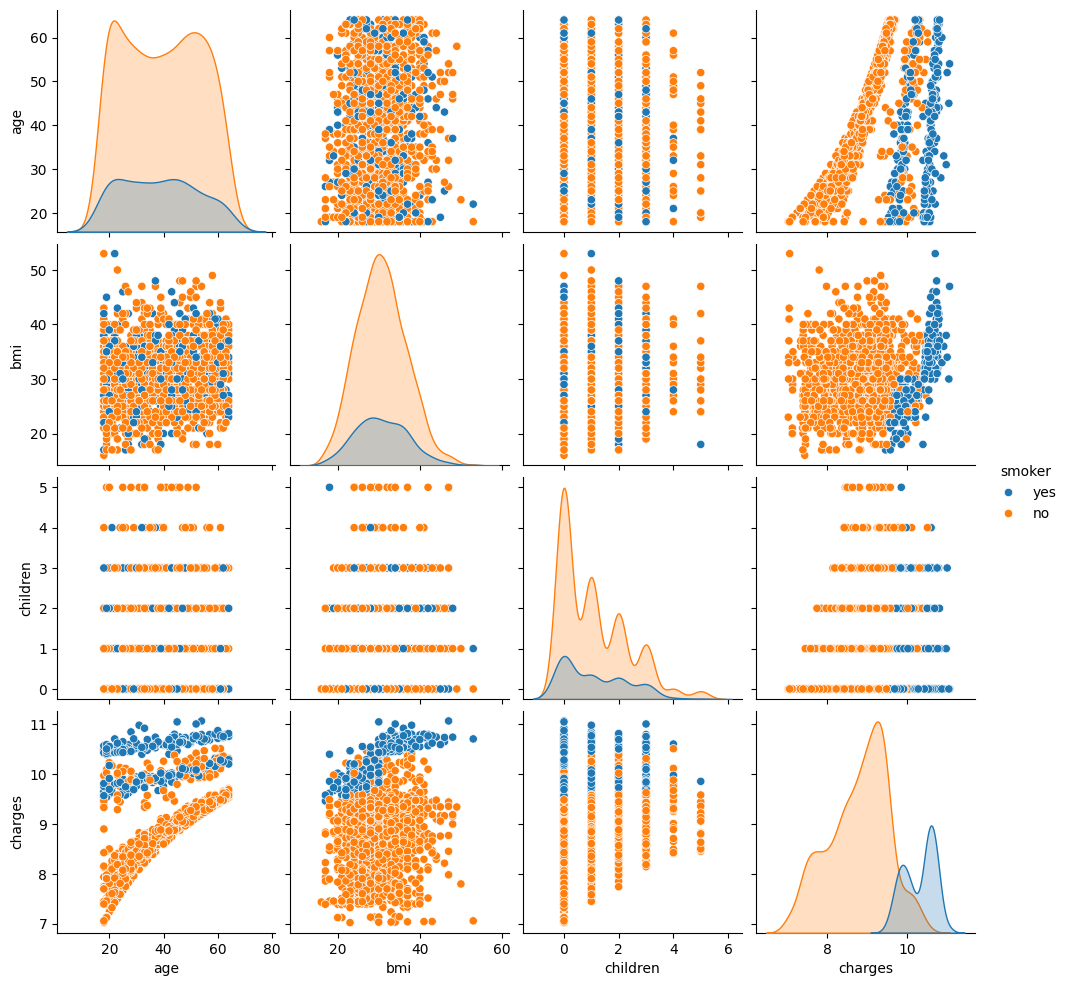

In [32]:
sns.pairplot(df, hue='smoker')

In [34]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,28,0,yes,southwest,9.734240
1,18,male,34,1,no,southeast,7.454141
2,28,male,33,3,no,southeast,8.400659
3,33,male,23,0,no,northwest,9.998116
4,32,male,29,0,no,northwest,8.260493


In [35]:
# feature engineering
df['age_squared'] = df['age'] ** 2
df['bmi_squared'] = df['bmi'] ** 2

df['smoker_age'] = (df['smoker'] == 'yes').astype(int) * df['age']
df['smoker_bmi'] = (df['smoker'] == 'yes').astype(int) * df['bmi']

In [36]:
df.head()

,age,sex,bmi,children,smoker,region,charges,age_squared,bmi_squared,smoker_age,smoker_bmi
0,19,female,28,0,yes,southwest,9.734240,361,784,19,28
1,18,male,34,1,no,southeast,7.454141,324,1156,0,0
2,28,male,33,3,no,southeast,8.400659,784,1089,0,0
3,33,male,23,0,no,northwest,9.998116,1089,529,0,0
4,32,male,29,0,no,northwest,8.260493,1024,841,0,0


In [43]:
X = df.drop('charges', axis=1)
y = df['charges']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
numeric_features = ['age', 'bmi', 'age_squared', 'bmi_squared', 'smoker_age', 'smoker_bmi']
binary_features = ['sex', 'smoker']
multi_class_features = ['region']

preprocessor = ColumnTransformer(
    [
        ('num', StandardScaler(), numeric_features),
        ('binary', OneHotEncoder(drop='if_binary'), binary_features),
        ('multi', OneHotEncoder(drop='first'), multi_class_features)
    ]
)

In [49]:
models = {
    'LinearRegression': 
    {
        'pipe': Pipeline([('prep', preprocessor), ('model', LinearRegression())]),
        'params': {}
    },

    'RandomForest':
    {
        'pipe': Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=42))]),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 10, 20],
            'model__min_samples_split': [2, 5]
        }
    },

    'GradientBoosting': 
    {
        'pipe': Pipeline([('prep', preprocessor), ('model', GradientBoostingRegressor(random_state=42))]),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5],
            'model__learning_rate': [0.01, 0.1, 0.2]
        }
    },

    'XGBRegressor':
    {
        'pipe': Pipeline([('prep', preprocessor), ('model', XGBRegressor(random_state=42))]),
        'params': {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [3, 5, 7],
            'model__learning_rate': [0.01, 0.1, 0.2],
            'model__subsample': [0.8, 1.0],
            'model__colsample_bytree': [0.8, 1.0]
        }
    }
}

In [54]:
# GridSearchCV

result = {}

for name, config in models.items():

    print(f'Training {name}...')

    grid = GridSearchCV(
        config['pipe'],
        config['params'],
        cv = 5,
        scoring = 'r2',
        n_jobs = -1
    )

    grid.fit(X_train, y_train)
    result[name] = {
        'best_score': grid.best_score_,
        'test_score': grid.score(X_test, y_test),
        'best_params': grid.best_params_
    }
    print(f'CV R^2: {grid.best_score_:.4f}, Test R^2: {grid.score(X_test, y_test):.4f}')

Training LinearRegression...
CV R^2: 0.8013, Test R^2: 0.8378
Training RandomForest...
CV R^2: 0.7658, Test R^2: 0.8012
Training GradientBoosting...
CV R^2: 0.7956, Test R^2: 0.8349
Training XGBRegressor...
CV R^2: 0.8014, Test R^2: 0.8326
